In [1]:
print("test")

test


In [2]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from kiwipiepy import Kiwi

kiwi = Kiwi()

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False


df = pd.read_csv("../data/11-1_뉴스정제.csv")
df[['제목','정제본문','카테고리']].head(3)

,제목,정제본문,카테고리
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...,경제
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...,경제


In [3]:
def extract_nouns(text):
    nouns = []

    # 토크나이저 적용
    result = kiwi.tokenize(text)

    for token in result:
        if token.tag.startswith("N"):  # N으로 시작하는 품사 = 명사 계열
            nouns.append(token.form)

    filtered_nouns = []

    for noun in nouns:
        if len(noun) > 1:
            filtered_nouns.append(noun)

    return filtered_nouns

In [5]:
# 모든 기사의 명사를 한곳에 모아서 합쳐서 빈도 세어 보기
all_nouns = []

df['명사'] = df['정제본문'].apply(extract_nouns)
df[['정제본문','명사']].head(3)


,정제본문,명사
0,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,"[서울, 연합뉴스, 현대백화점그룹, 광주광역시, 서울, 여의도, 현대, 서울, 문화..."
1,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...,"[전주, 뉴시스, 김얼, 기자, 이스타항공, 자금, 배임, 횡령, 전주, 교도소, ..."
2,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...,"[NH농협은행, 올해, 농협, 금융, 출범, 주년, 이달, 주년, 기념, 주화, 대..."


In [6]:
for doc_noun in df['명사']:
    all_nouns.extend(doc_noun)
print(len(all_nouns))    

179518


In [7]:
from collections import Counter
count_result = Counter(all_nouns)
count_result.most_common(10)

[('기업', 999),
 ('서비스', 920),
 ('사업', 851),
 ('기술', 777),
 ('제공', 748),
 ('시장', 687),
 ('개발', 657),
 ('국내', 599),
 ('투자', 592),
 ('가능', 557)]

In [9]:
# 불용어 
# 의미없는 단어라고 생각할때 -> 그 단어를 삭제
stopwords = ['기자','연합뉴스','뉴스','기업']

filtered_all_nouns = []

for noun in all_nouns:
    if noun not in stopwords:
        filtered_all_nouns.append(noun)


In [10]:
count_after = Counter(filtered_all_nouns)
count_after.most_common(20)

[('서비스', 920),
 ('사업', 851),
 ('기술', 777),
 ('제공', 748),
 ('시장', 687),
 ('개발', 657),
 ('국내', 599),
 ('투자', 592),
 ('가능', 557),
 ('올해', 544),
 ('계획', 541),
 ('대표', 530),
 ('서울', 524),
 ('금융', 522),
 ('지원', 506),
 ('정보', 503),
 ('진행', 491),
 ('고객', 461),
 ('이번', 456),
 ('산업', 449)]

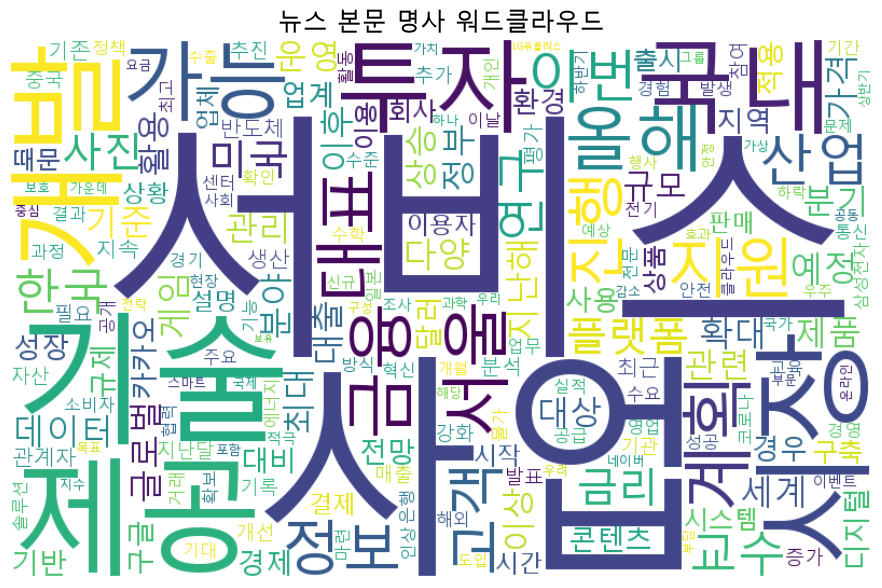

In [12]:
# 시각화 - 워드클라우드: 자주 나온 단어일수록 크게 표시합니다.
from wordcloud import WordCloud

# font_path를 지정하면 워드클라우드에서도 한글이 깨지지 않습니다.
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 너무 적게 나온 단어는 제외하여 핵심 단어가 더 잘 보이게 합니다.
wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="#101827",  # 차분한 남색 배경
    colormap="plasma",             # 보라·주황·노랑 계열 색상
    max_words=80,                      # 표시할 단어의 최대 개수
    min_font_size=12,
    prefer_horizontal=0.85,            # 대부분의 단어를 가로로 배치
    contour_width=1,
    contour_color="#38bdf8",
    random_state=42                    # 다시 실행해도 같은 배치가 나오도록 설정
).generate_from_frequencies(count_after)

# 그림 전체 배경과 제목을 워드클라우드 색상에 맞춥니다.
plt.figure(figsize=(14, 8), facecolor="#101827")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 그림 주변의 눈금과 테두리를 숨깁니다.
plt.title(
    "뉴스 본문 핵심 단어",
    fontsize=24,
    fontweight="bold",
    color="white",
    pad=18
)
plt.figtext(
    0.5, 0.04,
    "단어가 클수록 뉴스 본문에 자주 등장했습니다.",
    ha="center", fontsize=12, color="#cbd5e1"
)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


In [15]:
df = pd.read_csv("../data/11-1_visitjeju_reviews.csv")
df.head()
df[['리뷰내용']].head(3)

,리뷰내용
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ..."
2,메밀꽃 지평선과 하늘입니다


In [18]:
all_nouns = []

df["리뷰내용"] = df["리뷰내용"].fillna("")

df['리뷰내용_명사'] = df['리뷰내용'].apply(extract_nouns)
df[['리뷰내용','리뷰내용_명사']]

,리뷰내용,리뷰내용_명사
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,"[제주특별자치도, 서귀포시, 안덕면, 병악로, 위치, 카멜리아힐동백, 언덕, 친구,..."
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...","[성이시돌목, 테쉬폰, 우유부단, 왕따, 나무, 이색, 볼거리, 초원, 나무, 가운..."
2,메밀꽃 지평선과 하늘입니다,"[메밀꽃, 지평선, 하늘]"
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,[]
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,[]
...,...,...
5912,제주를 사랑하시는 저의 아버지는 겨울왕국이 있을 것처럼 눈이 소복하게 쌓인 한라산을...,"[제주, 사랑, 아버지, 겨울, 왕국, 한라산, 등반, 지금, 사진, 제주, 애정,..."
5913,중문 놀러왔다가 들렸어요~ 체험 할 거리도 많고 사진도 많이 찍을 수 있어서 좋았어...,"[중문, 체험, 거리, 사진, 그램, 콘서트, 공연, 별도, 요금, 체험, 체험, ..."
5914,#이호테우#이호테우말등대제주도여행 마지막 날 이호테우에서 아쉬움을 달래본다.,"[마지막, 이호테우, 아쉬움]"
5915,홀로 여행을 떠나 새로운각오을 다지고 왔어요.,"[여행, 각오]"


In [25]:
for doc_noun in df['리뷰내용_명사']:
    all_nouns.extend(doc_noun)
print(len(all_nouns))    

85486


In [26]:
from collections import Counter
count_result = Counter(all_nouns)
count_result.most_common(10)

[('제주', 3794),
 ('여행', 2042),
 ('제주도', 2010),
 ('바다', 1074),
 ('사진', 1024),
 ('시간', 618),
 ('가족', 604),
 ('한라산', 544),
 ('방문', 540),
 ('겨울', 540)]

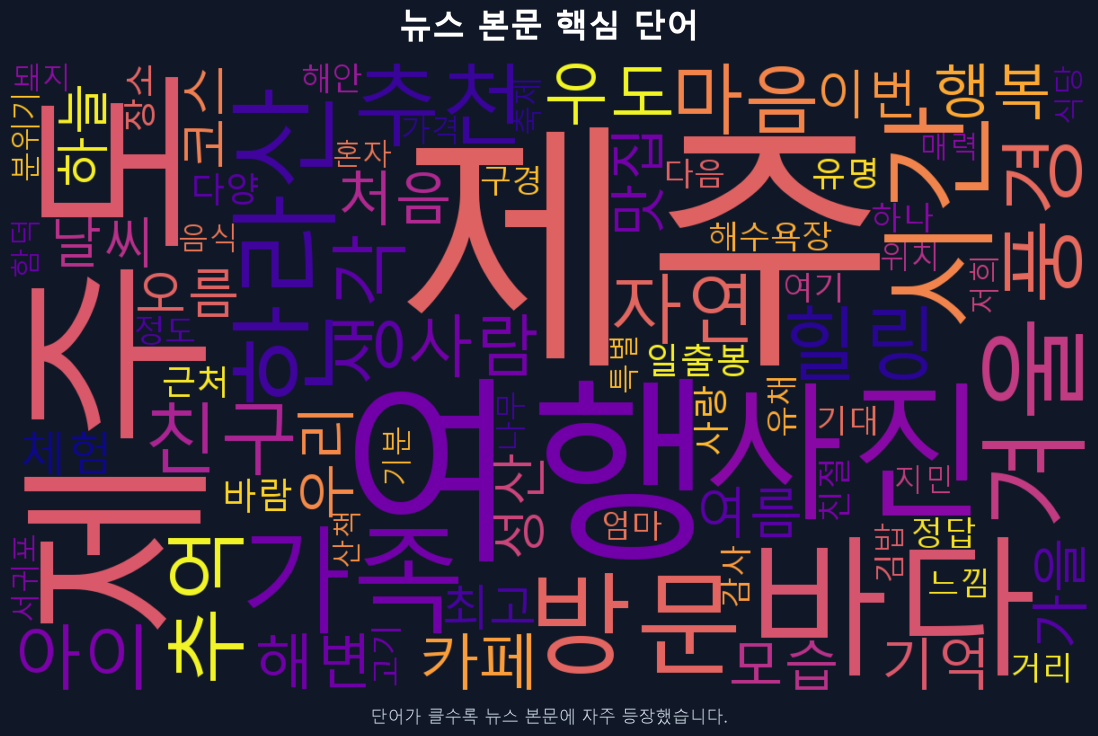

In [27]:
# 시각화 - 워드클라우드: 자주 나온 단어일수록 크게 표시합니다.
from wordcloud import WordCloud

# font_path를 지정하면 워드클라우드에서도 한글이 깨지지 않습니다.
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 너무 적게 나온 단어는 제외하여 핵심 단어가 더 잘 보이게 합니다.
wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="#101827",  # 차분한 남색 배경
    colormap="plasma",             # 보라·주황·노랑 계열 색상
    max_words=80,                      # 표시할 단어의 최대 개수
    min_font_size=12,
    prefer_horizontal=0.85,            # 대부분의 단어를 가로로 배치
    contour_width=1,
    contour_color="#38bdf8",
    random_state=42                    # 다시 실행해도 같은 배치가 나오도록 설정
).generate_from_frequencies(count_result)

# 그림 전체 배경과 제목을 워드클라우드 색상에 맞춥니다.
plt.figure(figsize=(14, 8), facecolor="#101827")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 그림 주변의 눈금과 테두리를 숨깁니다.
plt.title(
    "뉴스 본문 핵심 단어",
    fontsize=24,
    fontweight="bold",
    color="white",
    pad=18
)
plt.figtext(
    0.5, 0.04,
    "단어가 클수록 뉴스 본문에 자주 등장했습니다.",
    ha="center", fontsize=12, color="#cbd5e1"
)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
